# Explore here

In [1]:
import pandas as pd
adult_income_df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/predicting-your-future-with-data/main/adult-census-income.csv")
adult_income_df.head(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [2]:
adult_income_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [3]:
import numpy as np
adult_income_df.replace('?', np.nan, inplace=True)

In [4]:
def contar_NAN(ds):
    conteo = ds.isna().sum()
    return conteo
    

contiene_nan = adult_income_df.isna().any()

ds_NaN = pd.concat([contiene_nan,contar_NAN(adult_income_df)], axis=1)
ds_NaN.columns = ['Contiene NaN','Cantidad']
ds_NaN

,Contiene NaN,Cantidad
age,False,0
workclass,True,1836
fnlwgt,False,0
education,False,0
education.num,False,0
marital.status,False,0
occupation,True,1843
relationship,False,0
race,False,0
sex,False,0


In [5]:
df_adult_inc = adult_income_df.dropna()


In [6]:
contiene_nan_2 = df_adult_inc.isna().any()

ds_NaN_2 = pd.concat([contiene_nan_2,contar_NAN(df_adult_inc)], axis=1)
ds_NaN_2.columns = ['Contiene NaN','Cantidad']
ds_NaN_2

,Contiene NaN,Cantidad
age,False,0
workclass,False,0
fnlwgt,False,0
education,False,0
education.num,False,0
marital.status,False,0
occupation,False,0
relationship,False,0
race,False,0
sex,False,0


In [7]:
#Filtrar por las columnas de formato objet

#columnas numéricas
cols_num = df_adult_inc._get_numeric_data().columns

#columnas categóricas se pueden representar como la diferencia entre el total de columnas y las columnas numéricas
cols = df_adult_inc.columns
cols_cat = list(set(cols)-set(cols_num))
cols_cat

['relationship',
 'marital.status',
 'education',
 'workclass',
 'native.country',
 'race',
 'sex',
 'income',
 'occupation']

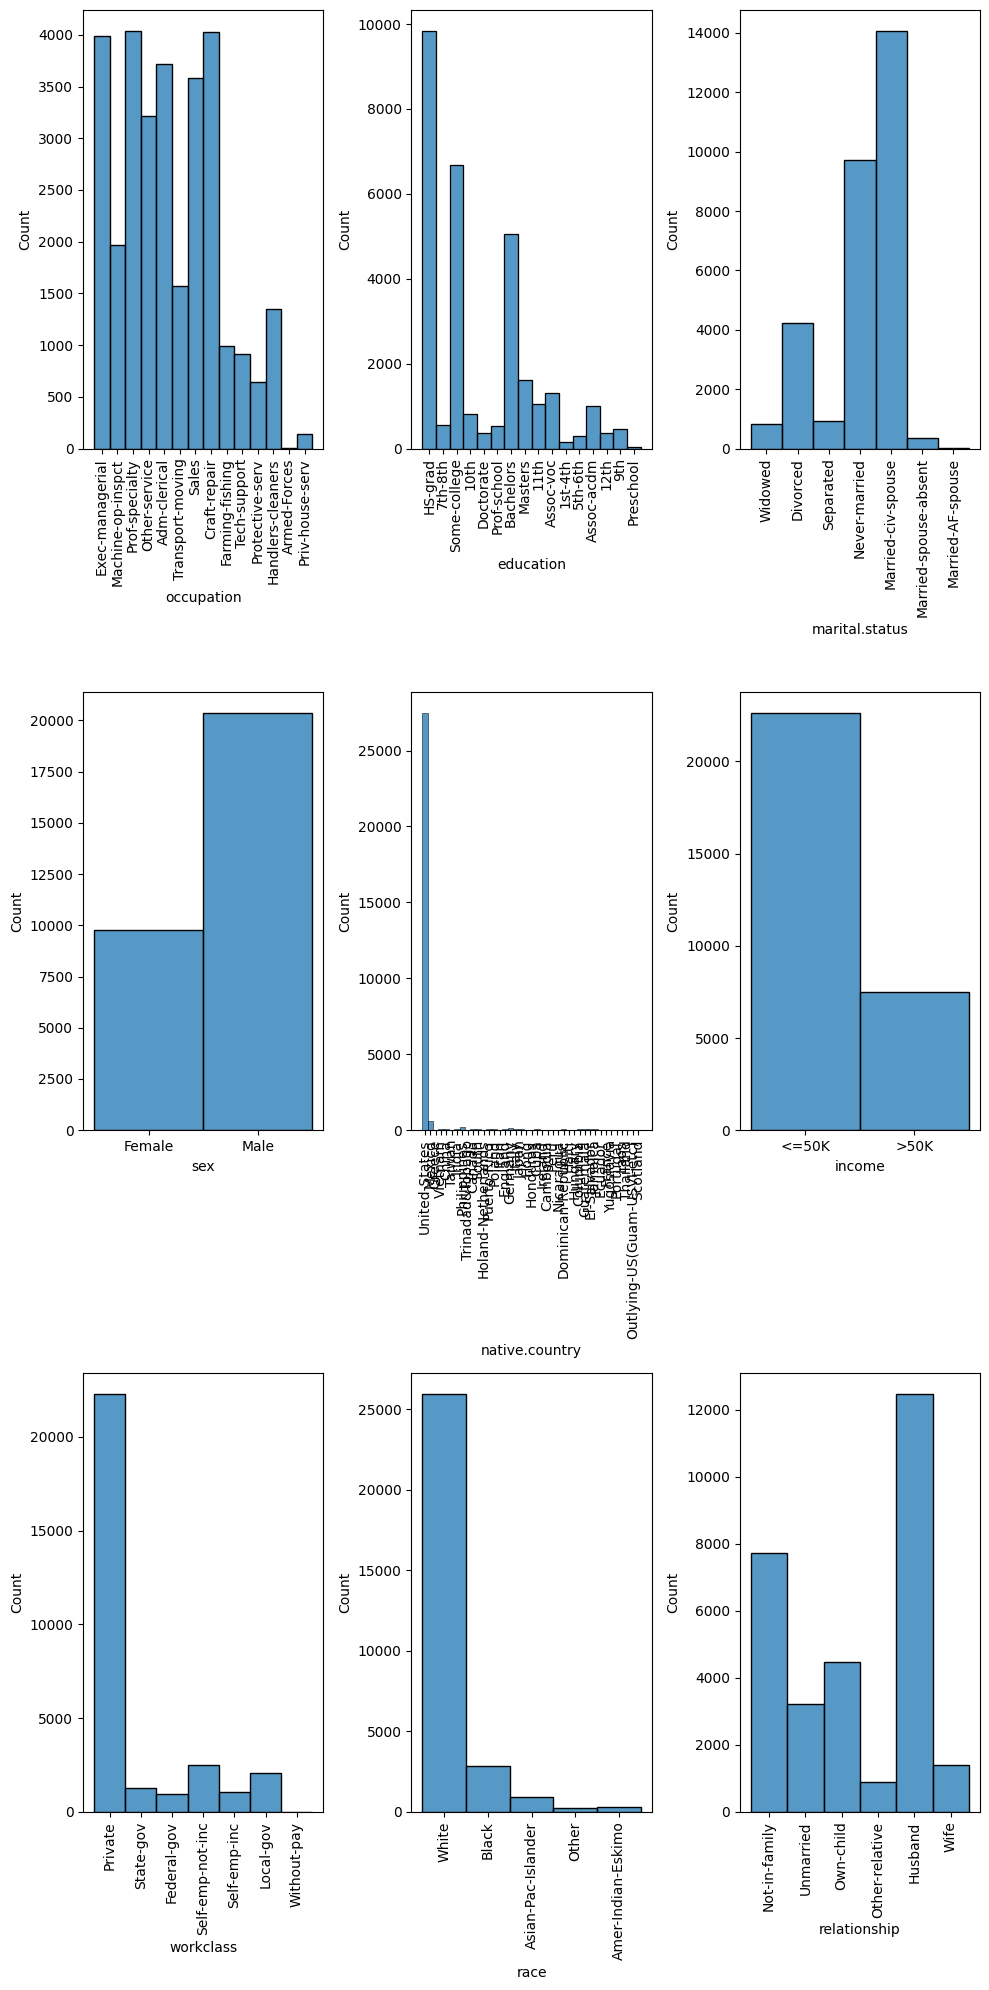

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(3,3,figsize=(10,20))
#histogramas de las variables
sns.histplot(ax= axis[0,0],data=df_adult_inc,x='occupation')
sns.histplot(ax= axis[0,1],data=df_adult_inc,x='education')#.set_xticks([])
sns.histplot(ax= axis[0,2],data=df_adult_inc,x='marital.status')#.set_xticks([])
sns.histplot(ax= axis[1,0],data=df_adult_inc,x='sex')
sns.histplot(ax= axis[1,1],data=df_adult_inc,x='native.country')
sns.histplot(ax= axis[1,2],data=df_adult_inc,x='income')
sns.histplot(ax= axis[2,0],data=df_adult_inc,x='workclass')
sns.histplot(ax= axis[2,1],data=df_adult_inc,x='race')
sns.histplot(ax= axis[2,2],data=df_adult_inc,x='relationship')

axis[0, 0].tick_params(axis='x', rotation=90)
axis[0, 1].tick_params(axis='x', rotation=90)
axis[0, 2].tick_params(axis='x', rotation=90)
axis[1, 1].tick_params(axis='x', rotation=90)
axis[2, 0].tick_params(axis='x', rotation=90)
axis[2, 1].tick_params(axis='x', rotation=90)
axis[2, 2].tick_params(axis='x', rotation=90)
#para borrar graficos en blanco
#fig.delaxes(axis[1,2])
#plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()


In [9]:
cols_num

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

<Axes: xlabel='hours.per.week'>

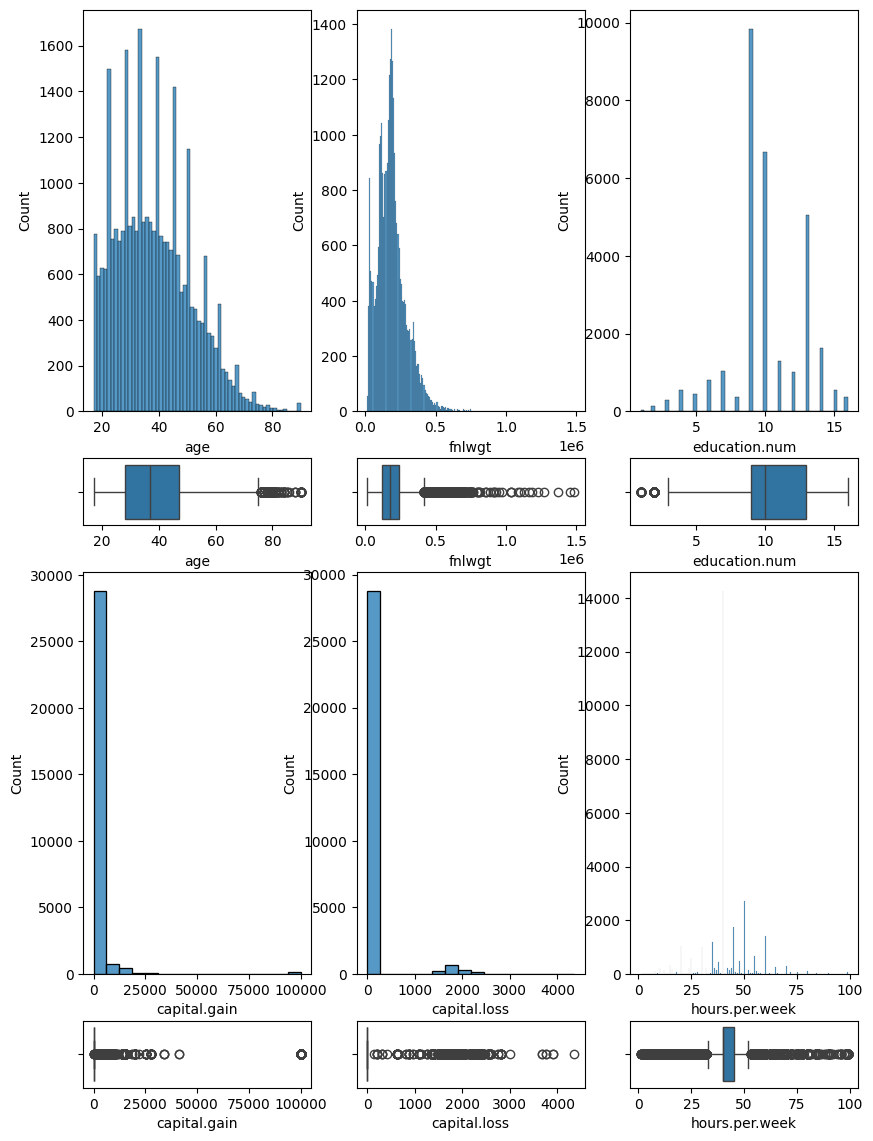

In [10]:
fig, axis = plt.subplots(4,3,figsize=(10,14),gridspec_kw={"height_ratios":[6,1,6,1]})

sns.histplot(ax= axis[0,0],data=df_adult_inc,x='age')
sns.boxplot(ax=axis[1,0],data=df_adult_inc,x='age')
sns.histplot(ax= axis[0,1],data=df_adult_inc,x='fnlwgt')#.set_xlim(0,60)
sns.boxplot(ax=axis[1,1],data=df_adult_inc,x='fnlwgt')#.set_xlim(0,60)
sns.histplot(ax= axis[0,2],data=df_adult_inc,x='education.num')#.set_xlim(0,60)
sns.boxplot(ax=axis[1,2],data=df_adult_inc,x='education.num')#.set_xlim(0,60)

sns.histplot(ax= axis[2,0],data=df_adult_inc,x='capital.gain')
sns.boxplot(ax=axis[3,0],data=df_adult_inc,x='capital.gain')
sns.histplot(ax= axis[2,1],data=df_adult_inc,x='capital.loss')#.set_xlim(0,100)
sns.boxplot(ax=axis[3,1],data=df_adult_inc,x='capital.loss')#.set_xlim(0,100)
sns.histplot(ax= axis[2,2],data=df_adult_inc,x='hours.per.week')#.set_xlim(0,100)
sns.boxplot(ax=axis[3,2],data=df_adult_inc,x='hours.per.week')#.set_xlim(0,100)

In [11]:

#agrega una variable numerica terminada en "_num" en el dataframe, que luego utilizafemos para reemplazar las variables categóricas
# si no agregamos la terminación "_num", la variable categorica será reemplazada por una numérica
for col in cols_cat:
    
    df_adult_inc[col+'_num'] = pd.factorize(df_adult_inc[col])[0]
df_adult_inc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 1 to 32560
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   age                 30162 non-null  int64 
 1   workclass           30162 non-null  object
 2   fnlwgt              30162 non-null  int64 
 3   education           30162 non-null  object
 4   education.num       30162 non-null  int64 
 5   marital.status      30162 non-null  object
 6   occupation          30162 non-null  object
 7   relationship        30162 non-null  object
 8   race                30162 non-null  object
 9   sex                 30162 non-null  object
 10  capital.gain        30162 non-null  int64 
 11  capital.loss        30162 non-null  int64 
 12  hours.per.week      30162 non-null  int64 
 13  native.country      30162 non-null  object
 14  income              30162 non-null  object
 15  relationship_num    30162 non-null  int64 
 16  marital.status_num  30162 n

C:\Users\macaya.diego_koperni\AppData\Local\Temp\ipykernel_16552\88399317.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_adult_inc[col+'_num'] = pd.factorize(df_adult_inc[col])[0]
C:\Users\macaya.diego_koperni\AppData\Local\Temp\ipykernel_16552\88399317.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_adult_inc[col+'_num'] = pd.factorize(df_adult_inc[col])[0]
C:\Users\macaya.diego_koperni\AppData\Local\Temp\ipykernel_16552\88399317.py:5: SettingWithCopyWarning: 
A value is trying to be set on 

In [13]:
df_num = df_adult_inc.drop(cols_cat,axis=1)
df_num.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,relationship_num,marital.status_num,education_num,workclass_num,native.country_num,race_num,sex_num,income_num,occupation_num
count,30162.000000,3.016200e+04,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1.897938e+05,10.121312,1092.007858,88.372489,40.931238,2.376931,3.100126,3.683542,0.841357,1.211922,0.213646,0.675685,0.248922,4.360221
std,13.134665,1.056530e+05,2.549995,7406.346497,404.298370,11.979984,1.758105,1.161214,3.807782,1.582725,5.161287,0.622172,0.468126,0.432396,3.097132
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,1.176272e+05,9.000000,0.000000,0.000000,40.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,37.000000,1.784250e+05,10.000000,0.000000,0.000000,40.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,4.000000
75%,47.000000,2.376285e+05,13.000000,0.000000,0.000000,45.000000,4.000000,4.000000,6.000000,1.000000,0.000000,0.000000,1.000000,0.000000,7.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,5.000000,6.000000,15.000000,6.000000,40.000000,4.000000,1.000000,1.000000,13.000000


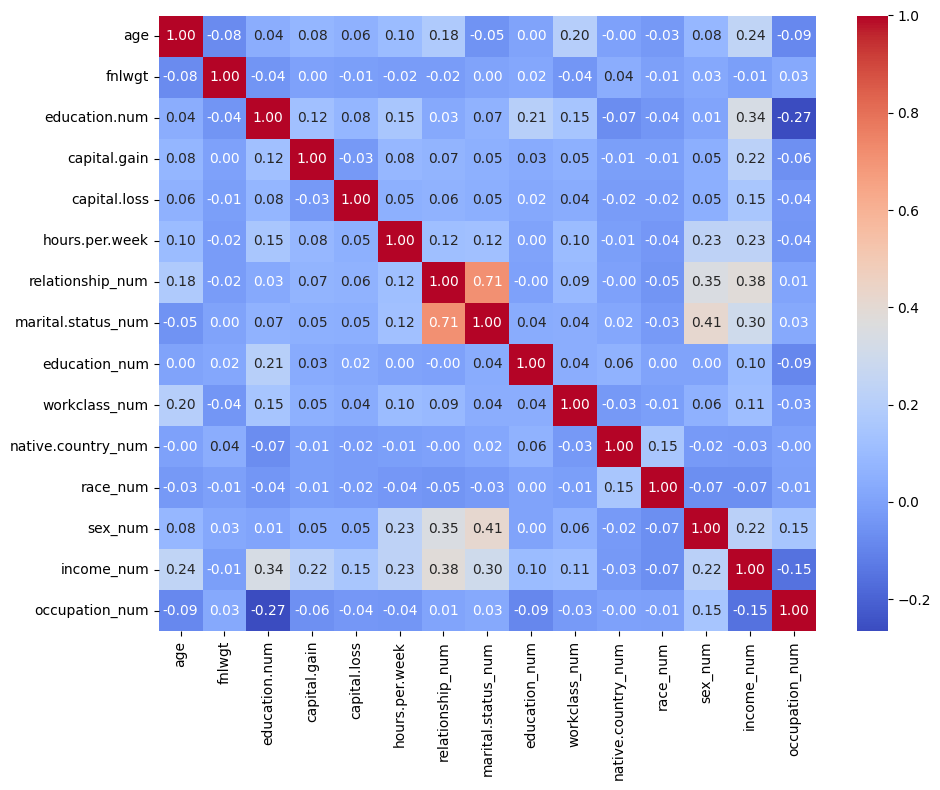

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_num.corr(), annot = True, fmt = ".2f", cmap='coolwarm', annot_kws={"size": 10})
plt.tight_layout()
plt.show()
